# 01A · Resumen base de general splits

Seguimiento sencillo del dashboard de equipos (Regular Season 2024-25) usando únicamente el parquet intermedio filtrado por `dataset = 0`. El objetivo es documentar:

- Filtrado del subset válido y verificación Win/Loss por franquicia.
- Tablas básicas de tiro y producción con diferenciales `W − L`.
- Rankings enfocados en anotación, puntería y margen de puntos.
- Visualizaciones descriptivas que resuman el comportamiento ofensivo.

---


## Configuración

Cargamos las dependencias (`pandas`, `matplotlib`, `seaborn`) y definimos rutas relativas tomando como raíz el repositorio. Se crean las carpetas donde se guardarán tablas y figuras del análisis.

---


In [77]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]
DATA_DIR = PROJECT_ROOT / "00_data"
FIGURES_DIR = PROJECT_ROOT / "00e_reports" / "figures" / "base_overview"
TABLES_DIR = PROJECT_ROOT / "00e_reports" / "tables" / "base_overview"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

INTERMEDIATE_PATH = (
    DATA_DIR
    / "00b_intermediate"
    / "team_dashboard"
    / "general_splits"
    / "2024-25"
    / "Regular Season"
    / "team_dashboard__general_splits.parquet"
)
DATASET_REFERENCE_ID = 0
SEASON_TARGET = "2024-25"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Parquet intermedio: {INTERMEDIATE_PATH}")
print(f"Dataset de referencia: {DATASET_REFERENCE_ID}")
print(f"Temporada objetivo: {SEASON_TARGET}")


Proyecto: /Users/pablo/Documents/BigData/BasketballAnalysis
Parquet intermedio: /Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00b_intermediate/team_dashboard/general_splits/2024-25/Regular Season/team_dashboard__general_splits.parquet
Dataset de referencia: 0
Temporada objetivo: 2024-25


## Carga y filtrado de datos

Leemos el parquet consolidado, ubicamos las columnas relevantes (`dataset`, `source_dataset`, `season`) y filtramos el subset solicitado (`dataset = 0`, `source_dataset = 0`, temporada 2024-25). Conservamos una copia completa para referencia rápida.

---


In [78]:
general_df = pd.read_parquet(INTERMEDIATE_PATH)

# Mapa case-insensitive
colmap = {c.lower(): c for c in general_df.columns}

df = general_df.copy()

# --- Filtro por dataset/source_dataset con OR ---
ds_col  = colmap.get("dataset")
sds_col = colmap.get("source_dataset")

if ds_col or sds_col:
    m_ds  = (df[ds_col].astype(str)  == str(DATASET_REFERENCE_ID)) if ds_col  else False
    m_sds = (df[sds_col].astype(str) == str(DATASET_REFERENCE_ID)) if sds_col else False
    df = df[m_ds | m_sds]

# --- Filtro por season (acepta season o season_year) ---
season_col = colmap.get("season") or colmap.get("season_year")
if season_col:
    df = df[df[season_col].astype(str) == str(SEASON_TARGET)]

# (Opcional) Filtro por season_type si lo estás usando
st_col = colmap.get("season_type")
if st_col and "SEASON_TYPE_TARGET" in globals() and SEASON_TYPE_TARGET:
    df = df[df[st_col].astype(str).str.casefold() == str(SEASON_TYPE_TARGET).casefold()]

analysis_df = df.copy()

print("general_df shape:", general_df.shape)
print("analysis_df shape:", analysis_df.shape)
print("dataset uniques:", general_df[colmap.get("dataset")].unique() if colmap.get("dataset") else "no 'dataset'")
print("source_dataset uniques:", general_df[colmap.get("source_dataset")].unique() if colmap.get("source_dataset") else "no 'source_dataset'")
print("season uniques:", general_df[season_col].unique() if season_col else "no season/season_year")


general_df shape: (672, 69)
analysis_df shape: (60, 69)
dataset uniques: ['dataset_0' 'dataset_1' 'dataset_2' 'dataset_3' 'dataset_4' 'dataset_5']
source_dataset uniques: [0 1 2 3 4 5]
season uniques: ['2024-25']


### Vista general del parquet filtrado

Mostramos las primeras filas para confirmar que únicamente quedan registros de la temporada objetivo y que se mantienen las columnas de tiro y producción solicitadas.

---


In [79]:
display(analysis_df.head())


,GROUP_SET,GROUP_VALUE,SEASON_YEAR,GP,W,L,W_PCT,MIN,FGM,FGA,...,dataset,TEAM_NAME,source_dataset,split_type,split_value,TEAM_GAME_LOCATION,GAME_RESULT,SEASON_MONTH_NAME,SEASON_SEGMENT,TEAM_DAYS_REST_RANGE
0,Overall,2024,2024,5,0,5,0.000,201.883333,140,357,...,dataset_0,Atlanta Hawks,0,overall,overall,None,None,None,None,None
1,Overall,2024-25,2024-25,82,40,42,0.488,3956.000000,3556,7528,...,dataset_0,Atlanta Hawks,0,overall,overall,None,None,None,None,None
2,Overall,2024,2024,5,2,3,0.400,200.000000,172,379,...,dataset_0,Boston Celtics,0,overall,overall,None,None,None,None,None
3,Overall,2024-25,2024-25,82,61,21,0.744,3966.000000,3413,7382,...,dataset_0,Boston Celtics,0,overall,overall,None,None,None,None,None
4,Overall,2024,2024,5,2,3,0.400,200.000000,169,372,...,dataset_0,Cleveland Cavaliers,0,overall,overall,None,None,None,None,None


## Normalización ligera de columnas

Para facilitar los cálculos posteriores trabajamos con una versión que usa nombres en mayúsculas. El DataFrame original se preserva para cualquier inspección adicional.

---


In [80]:
analysis_std = analysis_df.rename(columns={col: col.upper() for col in analysis_df.columns})
COLUMN_LOOKUP = {col: col for col in analysis_std.columns}

def require_columns(labels):
    missing = [label for label in labels if label not in COLUMN_LOOKUP]
    if missing:
        raise KeyError(f"Columnas faltantes en el parquet filtrado: {missing}")
    return [COLUMN_LOOKUP[label] for label in labels]

TEAM_KEYS = require_columns(["TEAM_ID", "TEAM_NAME"])
#RESULT_COL = require_columns(["GAME_RESULT"])[0]


## Validación Win/Loss por franquicia

Comprobamos que cada equipo disponga de exactamente dos filas (una victoria `W` y una derrota `L`). Reportamos el número de resultados distintos por equipo y resaltamos cualquier caso atípico.

---


In [81]:
win_loss_counts = (
    analysis_std
    .groupby(TEAM_KEYS, dropna=False)[["W", "L"]]
    .sum(min_count=1)   # suma por equipo
)

win_loss_summary = win_loss_counts.assign(TOTAL=lambda df: df["W"] + df["L"])

anomalies = win_loss_summary[
    (win_loss_summary["W"] == 0) | (win_loss_summary["L"] == 0)
]

display(win_loss_summary)
print("Shape:", win_loss_summary.shape)
print(win_loss_summary.head())

if not anomalies.empty:
    print("⚠️ Equipos sin par W/L completo:")
    display(anomalies)
else:
    print("✅ Todos los equipos tienen registros de victoria y derrota.")


,,W,L,TOTAL
TEAM_ID,TEAM_NAME,,,
1610612737,Atlanta Hawks,40,47,87
1610612738,Boston Celtics,63,24,87
1610612739,Cleveland Cavaliers,66,21,87
1610612740,New Orleans Pelicans,21,66,87
1610612741,Chicago Bulls,41,46,87
1610612742,Dallas Mavericks,40,47,87
1610612743,Denver Nuggets,52,35,87
1610612744,Golden State Warriors,55,35,90
1610612745,Houston Rockets,54,33,87


Shape: (30, 3)
                                  W   L  TOTAL
TEAM_ID    TEAM_NAME                          
1610612737 Atlanta Hawks         40  47     87
1610612738 Boston Celtics        63  24     87
1610612739 Cleveland Cavaliers   66  21     87
1610612740 New Orleans Pelicans  21  66     87
1610612741 Chicago Bulls         41  46     87
✅ Todos los equipos tienen registros de victoria y derrota.


## Tablas de tiro y producción (W vs L)

Construimos tablas para victorias y derrotas con métricas básicas de anotación y juego colectivo. También calculamos el diferencial \( \Delta = 	ext{W} - 	ext{L} \) para cada métrica, incluyendo un campo \(W_{	ext{total}} - L_{	ext{total}}\) que resume el margen agregado.

Las métricas analizadas son:

- Volumen: `GP`, `MIN`, `FGM`, `FGA`, `FG3M`, `FG3A`, `FTM`, `FTA`, `OREB`, `DREB`, `REB`, `AST`, `TOV`, `PTS`.
- Eficiencia: `W_PCT`, `FG_PCT`, `FG3_PCT`, `FT_PCT`, `PLUS_MINUS`.

---


In [82]:
metricas = [
    "GP", "W", "L", "W_PCT", "MIN",
    "FGM", "FGA", "FG_PCT",
    "FG3M", "FG3A", "FG3_PCT",
    "FTM", "FTA", "FT_PCT",
    "OREB", "DREB", "REB",
    "AST", "TOV",
    "PTS", "PLUS_MINUS",
]
metric_cols = require_columns(metricas)
metrics_map = dict(zip(metricas, metric_cols))

win_df = (
    analysis_std[analysis_std[RESULT_COL] == "W"]
    .sort_values(COLUMN_LOOKUP["TEAM_NAME"])
    .set_index(TEAM_KEYS)[metric_cols]
)
loss_df = (
    analysis_std[analysis_std[RESULT_COL] == "L"]
    .sort_values(COLUMN_LOOKUP["TEAM_NAME"])
    .set_index(TEAM_KEYS)[metric_cols]
)

win_table = win_df.rename(columns={metrics_map[k]: f"{k}_WIN" for k in metricas})
loss_table = loss_df.rename(columns={metrics_map[k]: f"{k}_LOSS" for k in metricas})

diff_df = win_df - loss_df

diff_table = diff_df.rename(columns={metrics_map[k]: f"{k}_DIFF" for k in metricas})
diff_table["W_MINUS_L"] = win_df[metrics_map["W"]] - loss_df[metrics_map["L"]]

summary_table = (
    win_table
    .join(loss_table, how="inner")
    .join(diff_table, how="inner")
)

summary_reset = summary_table.reset_index()

display(summary_reset.head())

summary_path = TABLES_DIR / "resumen_w_l_metrics.csv"
summary_reset.to_csv(summary_path, index=False)
print("Resumen exportado a", summary_path)


,TEAM_ID,TEAM_NAME,GP_WIN,W_WIN,L_WIN,W_PCT_WIN,MIN_WIN,FGM_WIN,FGA_WIN,FG_PCT_WIN,...,FTA_DIFF,FT_PCT_DIFF,OREB_DIFF,DREB_DIFF,REB_DIFF,AST_DIFF,TOV_DIFF,PTS_DIFF,PLUS_MINUS_DIFF,W_MINUS_L


Resumen exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/tables/base_overview/resumen_w_l_metrics.csv


## Rankings enfocados en anotación y margen

Generamos tres rankings:

1. Diferencial de puntos (`PTS_DIFF`).
2. Mejora de porcentaje de campo (`FG_PCT_DIFF`).
3. Margen de `PLUS_MINUS_DIFF`.

Cada tabla incluye la posición (`rank`) calculada con el método *dense* para facilitar comparaciones.

---


In [83]:
diff_reset = summary_table.reset_index()

rank_specs = [
    ("PTS_DIFF", False, "ranking_pts_diff.csv"),
    ("FG_PCT_DIFF", False, "ranking_fg_pct_diff.csv"),
    ("PLUS_MINUS_DIFF", False, "ranking_plus_minus_diff.csv"),
]

rank_results = {}
for metric, ascending, filename in rank_specs:
    if metric in diff_reset.columns:
        ranked = (
            diff_reset
            .sort_values(metric, ascending=ascending)
            .assign(**{f"{metric}_RANK": lambda df, m=metric, asc=ascending: df[m].rank(method="dense", ascending=asc).astype(int)})
        )
        rank_results[metric] = ranked
        output_path = TABLES_DIR / filename
        ranked.to_csv(output_path, index=False)
        print(f"Ranking '{metric}' exportado a {output_path}")
    else:
        print(f"⚠️ No se encontró la columna {metric} en el resumen, se omite el ranking.")

for metric, ranked in rank_results.items():
    display(ranked.head())


Ranking 'PTS_DIFF' exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/tables/base_overview/ranking_pts_diff.csv
Ranking 'FG_PCT_DIFF' exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/tables/base_overview/ranking_fg_pct_diff.csv
Ranking 'PLUS_MINUS_DIFF' exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/00e_reports/tables/base_overview/ranking_plus_minus_diff.csv


,TEAM_ID,TEAM_NAME,GP_WIN,W_WIN,L_WIN,W_PCT_WIN,MIN_WIN,FGM_WIN,FGA_WIN,FG_PCT_WIN,...,FT_PCT_DIFF,OREB_DIFF,DREB_DIFF,REB_DIFF,AST_DIFF,TOV_DIFF,PTS_DIFF,PLUS_MINUS_DIFF,W_MINUS_L,PTS_DIFF_RANK


,TEAM_ID,TEAM_NAME,GP_WIN,W_WIN,L_WIN,W_PCT_WIN,MIN_WIN,FGM_WIN,FGA_WIN,FG_PCT_WIN,...,FT_PCT_DIFF,OREB_DIFF,DREB_DIFF,REB_DIFF,AST_DIFF,TOV_DIFF,PTS_DIFF,PLUS_MINUS_DIFF,W_MINUS_L,FG_PCT_DIFF_RANK


,TEAM_ID,TEAM_NAME,GP_WIN,W_WIN,L_WIN,W_PCT_WIN,MIN_WIN,FGM_WIN,FGA_WIN,FG_PCT_WIN,...,FT_PCT_DIFF,OREB_DIFF,DREB_DIFF,REB_DIFF,AST_DIFF,TOV_DIFF,PTS_DIFF,PLUS_MINUS_DIFF,W_MINUS_L,PLUS_MINUS_DIFF_RANK


## ΔPTS por equipo

Gráfico de barras con el diferencial de puntos (victorias − derrotas). Permite identificar rápidamente qué equipos amplían su anotación cuando ganan.

---


ValueError: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_capstyle

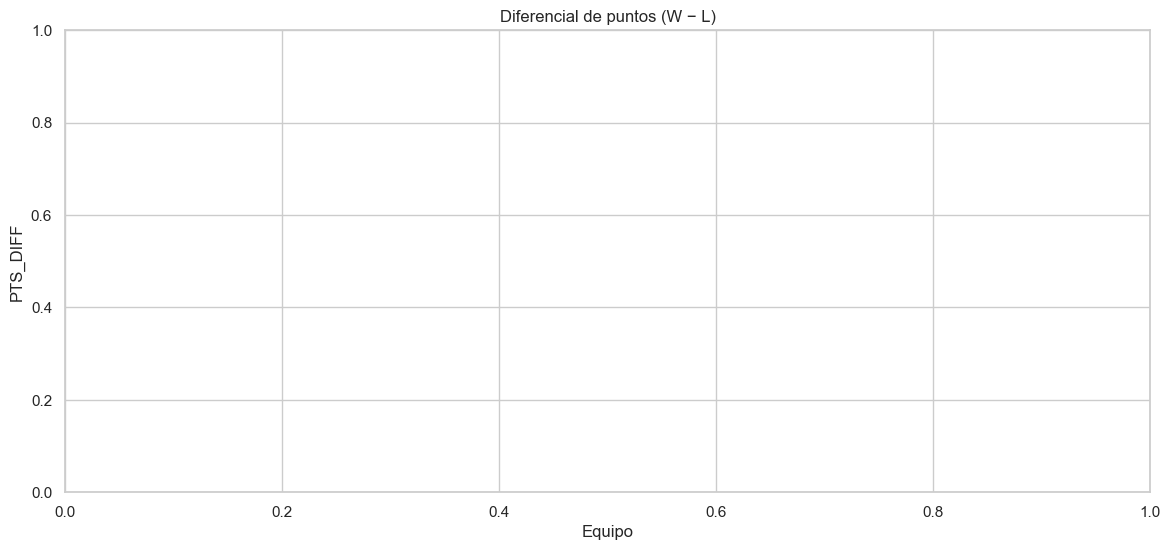

In [84]:
pts_metric = "PTS_DIFF"
if pts_metric in diff_reset.columns:
    bar_df = diff_reset.sort_values(pts_metric, ascending=False)
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=bar_df, x=COLUMN_LOOKUP["TEAM_NAME"], y=pts_metric, ax=ax)
    ax.set_title("Diferencial de puntos (W − L)")
    ax.set_xlabel("Equipo")
    ax.set_ylabel("PTS_DIFF")
    ax.tick_params(axis="x", rotation=45, ha="right")
    plt.tight_layout()
    figure_path = FIGURES_DIR / "bar_pts_diff.png"
    fig.savefig(figure_path, dpi=150)
    plt.show()
    print("Figura guardada en", figure_path)
else:
    print("⚠️ No hay columna PTS_DIFF para graficar.")


## Porcentajes de tiro: W vs L

Comparación de `FG_PCT`, `FG3_PCT` y `FT_PCT` entre victorias y derrotas mediante barras agrupadas. Los valores se transforman a formato largo para facilitar la visualización.

---


In [ ]:
percentage_metrics = ["FG_PCT", "FG3_PCT", "FT_PCT"]
percentage_cols = [f"{metric}_WIN" for metric in percentage_metrics] + [f"{metric}_LOSS" for metric in percentage_metrics]

if all(col in summary_reset.columns for col in percentage_cols):
    plot_df = summary_reset[[COLUMN_LOOKUP["TEAM_NAME"]] + percentage_cols].melt(
        id_vars=COLUMN_LOOKUP["TEAM_NAME"],
        var_name="METRIC",
        value_name="VALUE",
    )
    plot_df[["STAT", "RESULT"]] = plot_df["METRIC"].str.rsplit("_", n=1, expand=True)
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=plot_df, x=COLUMN_LOOKUP["TEAM_NAME"], y="VALUE", hue="RESULT", palette="Set2", ax=ax)
    ax.set_title("Porcentajes de tiro según resultado")
    ax.set_xlabel("Equipo")
    ax.set_ylabel("Porcentaje")
    ax.tick_params(axis="x", rotation=45, ha="right")
    plt.legend(title="Resultado")
    plt.tight_layout()
    figure_path = FIGURES_DIR / "bar_shooting_percentages.png"
    fig.savefig(figure_path, dpi=150)
    plt.show()
    print("Figura guardada en", figure_path)
else:
    print("⚠️ No se encontraron todas las columnas de porcentajes para la comparativa.")


## Dispersión: FGA vs PTS

Relación entre intentos de campo (`FGA`) y puntos anotados (`PTS`) diferenciando victorias y derrotas. Ayuda a ver si el volumen de tiro explica la producción ofensiva.

---


In [ ]:
fga_col, pts_col = require_columns(["FGA", "PTS"])
scatter_cols = [fga_col, pts_col, RESULT_COL, COLUMN_LOOKUP["TEAM_NAME"]]
scatter_df = analysis_std[scatter_cols].rename(columns={
    fga_col: "FGA",
    pts_col: "PTS",
    RESULT_COL: "RESULTADO",
    COLUMN_LOOKUP["TEAM_NAME"]: "TEAM_NAME",
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x="FGA", y="PTS", hue="RESULTADO", style="RESULTADO", ax=ax)
ax.set_title("Relación FGA vs PTS")
ax.set_xlabel("Intentos de campo (FGA)")
ax.set_ylabel("Puntos (PTS)")
plt.tight_layout()
figure_path = FIGURES_DIR / "scatter_fga_pts.png"
fig.savefig(figure_path, dpi=150)
plt.show()
print("Figura guardada en", figure_path)


## Distribución de FG_PCT

Histograma con densidad (`KDE`) que compara la distribución del porcentaje de campo entre victorias y derrotas.

---


In [ ]:
fg_pct_col = require_columns(["FG_PCT"])[0]
dist_df = analysis_std[[fg_pct_col, RESULT_COL]].rename(columns={
    fg_pct_col: "FG_PCT",
    RESULT_COL: "RESULTADO",
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=dist_df, x="FG_PCT", hue="RESULTADO", kde=True, element="step", stat="density", common_norm=False, ax=ax)
ax.set_title("Distribución del FG% por resultado")
ax.set_xlabel("FG_PCT")
plt.tight_layout()
figure_path = FIGURES_DIR / "hist_fg_pct.png"
fig.savefig(figure_path, dpi=150)
plt.show()
print("Figura guardada en", figure_path)


## Correlación de métricas clave

Calculamos una matriz de correlación con variables ofensivas básicas (`W_PCT`, porcentajes de tiro, rebotes, asistencias, pérdidas, puntos y margen). Esto ayuda a identificar qué indicadores se mueven juntos.

---


In [ ]:
corr_metrics = [
    "W_PCT", "FG_PCT", "FG3_PCT", "FT_PCT",
    "OREB", "DREB", "REB",
    "AST", "TOV",
    "PTS", "PLUS_MINUS",
]
corr_cols = require_columns(corr_metrics)

corr_df = analysis_std[corr_cols].rename(columns=dict(zip(corr_cols, corr_metrics)))

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
ax.set_title("Correlaciones de métricas ofensivas")
plt.tight_layout()
figure_path = FIGURES_DIR / "heatmap_correlation.png"
fig.savefig(figure_path, dpi=150)
plt.show()
print("Figura guardada en", figure_path)
